# Обучение модели и анализ динамики

Ноутбук выполняет обучение трёхмерной сегментационной модели гиппокампа, анализирует
динамику обучения и оценивает качество полученной модели на отложенной валидационной
подвыборке. Используются компоненты, верифицированные в предыдущих ноутбуках: конвейер
данных (`02_data_pipeline.ipynb`) и модель с функцией потерь и метриками
(`03_model_and_losses.ipynb`). Содержание следует структуре медицинского исследования:
введению с постановкой задачи оптимизации, описанию материалов и методов, результатам
обучения и обсуждению.


## Введение

### Задача оптимизации

Обучение сегментационной модели формулируется как задача минимизации функции потерь по
параметрам модели на обучающей подвыборке. Численно решение задачи строится методом
итеративного обновления параметров стохастическим градиентным спуском по мини-батчам, при
котором на каждом шаге вычисляется градиент функции потерь по параметрам модели на одном
батче и применяется правило обновления параметров оптимизатора. Сходимость оценивается по
изменению значения функции потерь на обучающей подвыборке и метрик качества на отдельной
валидационной подвыборке, не участвующей в обновлении параметров.

В медицинской сегментации задача оптимизации обладает рядом особенностей. Размер обучающей
подвыборки, как правило, на порядки меньше типичного размера обучающих наборов
естественных изображений: построение крупных размеченных наборов медицинских данных
ограничено стоимостью и продолжительностью экспертной разметки. Это определяет высокий
риск переобучения и требует средств его контроля: ранней остановки, регуляризации,
аугментации обучающей выборки. Существенен также выбор основной метрики качества для отбора
итоговой модели: метрика должна отражать клиническую значимость результата, а не только
формальное соответствие предсказания эталону.

### Используемые компоненты

Все компоненты, необходимые для обучения, верифицированы в предыдущих ноутбуках и здесь
используются как готовые. Конвейер данных формирует загрузчики обучающей (208 исследований)
и валидационной (52 исследования) подвыборок с детерминированным препроцессингом и
стохастической аугментацией обучающей выборки. Модель — трёхмерная U-Net с приблизительно
4.8 миллиона обучаемых параметров. Функция потерь — комбинация Dice и Cross-Entropy с
включением фонового класса. Метрики качества — коэффициент Дайса и 95-й процентиль
расстояния Хаусдорфа, вычисляемые раздельно по классам переднего плана и усредняемые.

### Цель ноутбука

Ноутбук решает следующие задачи:

1. Запустить или возобновить обучение модели в соответствии с конфигурацией проекта.
2. Зарегистрировать историю обучения и сохранить чекпойнты согласно политике сохранения.
3. Проанализировать динамику функции потерь и валидационных метрик: характер сходимости,
   наличие признаков переобучения, эпоху, на которой достигнут наилучший результат.
4. Оценить итоговое качество сегментации по численным метрикам в сопоставлении с
   литературными ориентирами.
5. Качественно проверить предсказания модели на примерах валидационной выборки.


## Материалы и методы

### Алгоритм оптимизации

Применяется адаптивный градиентный метод **Adam** (Kingma and Ba, 2015) с параметрами по
умолчанию, за исключением шага обучения и регуляризации. Adam поддерживает экспоненциально
сглаженные оценки первых и вторых моментов градиента, что обеспечивает сходимость без
ручной настройки расписания шага в широком диапазоне задач и является стандартным выбором
для обучения сегментационных моделей.

* **Начальный шаг обучения `learning_rate = 1e-3`** — общепринятое начальное значение для
  Adam в задачах сегментации; обеспечивает быстрое снижение функции потерь на ранних
  эпохах и устойчивость в дальнейшем.
* **Регуляризация весов `weight_decay = 1e-5`** — слабая регуляризация второго порядка,
  предотвращающая неограниченный рост значений параметров без существенного смещения
  оптимума.
* Расписание шага обучения не применяется: при наблюдаемой устойчивой сходимости в
  пределах 100 эпох введение расписания (cosine annealing, step decay) не требуется.

### Цикл обучения

Одна эпоха состоит из последовательного применения двух процедур:

* **Обучающая фаза** — проход по обучающей подвыборке с обновлением параметров: для каждого
  батча вычисляется прямой проход модели, значение функции потерь, обратный проход с
  вычислением градиентов и шаг оптимизатора. Регистрируется среднее значение функции потерь
  по батчам эпохи.
* **Валидационная фаза** — проход по валидационной подвыборке без обновления параметров и
  без вычисления градиентов: для каждого батча вычисляется прямой проход, постобработка
  выхода модели для метрик (softmax → argmax → one-hot) и пополнение состояния агрегаторов
  метрик. После прохода метрики агрегируются по подвыборке.

Общая длительность обучения определяется параметром `max_epochs = 100`. Этого числа эпох
достаточно для достижения насыщения значений валидационных метрик на данной задаче и
исключает преждевременное прекращение обучения. Размер мини-батча `batch_size = 4` подобран
с учётом памяти графического процессора и обеспечивает достаточно частое обновление
параметров при стабильной оценке градиента.

### Политика сохранения чекпойнтов

Применяются два независимых чекпойнта:

* **`last.pt`** — перезаписываемый чекпойнт последнего состояния обучения: параметры модели,
  состояние оптимизатора, номер последней завершённой эпохи, история метрик и значение
  основной метрики наилучшей модели. Назначение — возобновление обучения после прерывания
  сессии без потери прогресса. В среде облачного исполнения с ограниченным временем
  сессии (Google Colab) это существенно: возобновление обеспечивает практическую
  осуществимость длительного обучения.
* **`best.pt`** — веса модели с наилучшим значением основной валидационной метрики из всех
  завершённых эпох. Назначение — итоговая модель для последующих оценок и применения;
  такая политика устойчива к ухудшению качества на поздних эпохах вследствие переобучения.

### Критерий отбора лучшей модели

Основная метрика отбора — **коэффициент Дайса** на валидационной подвыборке, агрегированный
средним по классам переднего плана. Коэффициент Дайса максимизируется; модель текущей эпохи
сохраняется как наилучшая, если её валидационное значение превосходит ранее достигнутое.

Выбор коэффициента Дайса в качестве основной метрики отбора обоснован:

* Дайс — стандарт оценки в медицинской сегментации, обеспечивающий сопоставимость
  результата с литературными показателями.
* Метрика интерпретируется как объёмное перекрытие, непосредственно связанное с клинически
  значимыми приложениями (морфометрия, оценка объёма структуры).
* В отличие от расстояния Хаусдорфа, коэффициент Дайса численно стабилен в крайних
  режимах и пригоден для прямого сравнения между эпохами без дополнительной обработки
  выбросов.

Расстояние Хаусдорфа отслеживается параллельно как дополнительная мера геометрической
точности границ, но не служит критерием отбора.

### Литературные ориентиры качества

Для задачи Task04 (Hippocampus) Medical Segmentation Decathlon опубликованные значения
коэффициента Дайса находятся в диапазоне приблизительно **0.85–0.90** при использовании
свёрточных архитектур семейства U-Net с типичным конвейером препроцессинга и аугментации
(Antonelli et al., *Nat Commun* 2022; решения участников MSD). Значения существенно выше
этого диапазона достигаются преимущественно ансамблевыми моделями и специализированными
архитектурами; значения ниже указывают на дефекты конвейера обучения. Этот диапазон
используется как ориентир при интерпретации полученного результата.


## Подготовка среды исполнения


In [1]:
!pip install -q "monai[nibabel,tqdm]==1.5.1" "nibabel==5.2.1" matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 86.5 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import sys
import json
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/hippocampus-segmentation")
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch

from monai.utils import set_determinism
from src.config import cfg
from src import train_engine

# Фиксация генераторов случайных чисел.
set_determinism(seed=cfg.seed)

# Единый стиль визуализаций.
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titlepad": 8,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.titlesize": 12.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
})

print(f"Архитектура       : {cfg.model_name}")
print(f"Число классов     : {cfg.num_classes}")
print(f"Размер входа      : {cfg.spatial_size}")
print(f"Размер батча      : {cfg.batch_size}")
print(f"Шаг обучения      : {cfg.learning_rate}")
print(f"Регуляризация     : {cfg.weight_decay}")
print(f"Эпох максимум     : {cfg.max_epochs}")
print(f"Каталог чекпойнтов: {cfg.checkpoint_dir}")


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Архитектура       : unet
Число классов     : 3
Размер входа      : (48, 64, 48)
Размер батча      : 4
Шаг обучения      : 0.001
Регуляризация     : 1e-05
Эпох максимум     : 100
Каталог чекпойнтов: /content/drive/MyDrive/hippocampus-segmentation/checkpoints/Task04_Hippocampus


## Результаты обучения

### 1. Запуск обучения

Обучение выполняется управляющим циклом модуля `train_engine`. При наличии сохранённого
состояния (`last.pt`) обучение возобновляется с эпохи, следующей за последней завершённой,
что обеспечивает устойчивость к прерыванию сессии Colab. По завершении каждой эпохи
проводится валидация, регистрируются метрики, обновляются чекпойнты согласно политике
сохранения. Если все запланированные эпохи уже выполнены, функция возвращает зарегистрированную
историю без повторного обучения.


In [4]:
history = train_engine.train(cfg, resume=True)


Loading dataset: 100%|██████████| 52/52 [00:21<00:00,  2.44it/s]


training already complete: 100 epochs passed | best Dice 0.8713


По завершении функции возвращается история обучения — два массива длины `max_epochs`:
среднее значение функции потерь на обучающей подвыборке по эпохам и значения валидационных
метрик. История используется для построения кривых обучения и анализа динамики.


### 2. Динамика функции потерь и валидационных метрик

Динамика трёх показателей по эпохам характеризует сходимость: функция потерь на обучающей
подвыборке должна монотонно убывать; коэффициент Дайса на валидационной подвыборке —
возрастать и стабилизироваться; 95-й процентиль расстояния Хаусдорфа — убывать и
стабилизироваться. На графики дополнительно нанесены маркеры эпохи с наилучшим значением
коэффициента Дайса и соответствующих значений всех показателей.


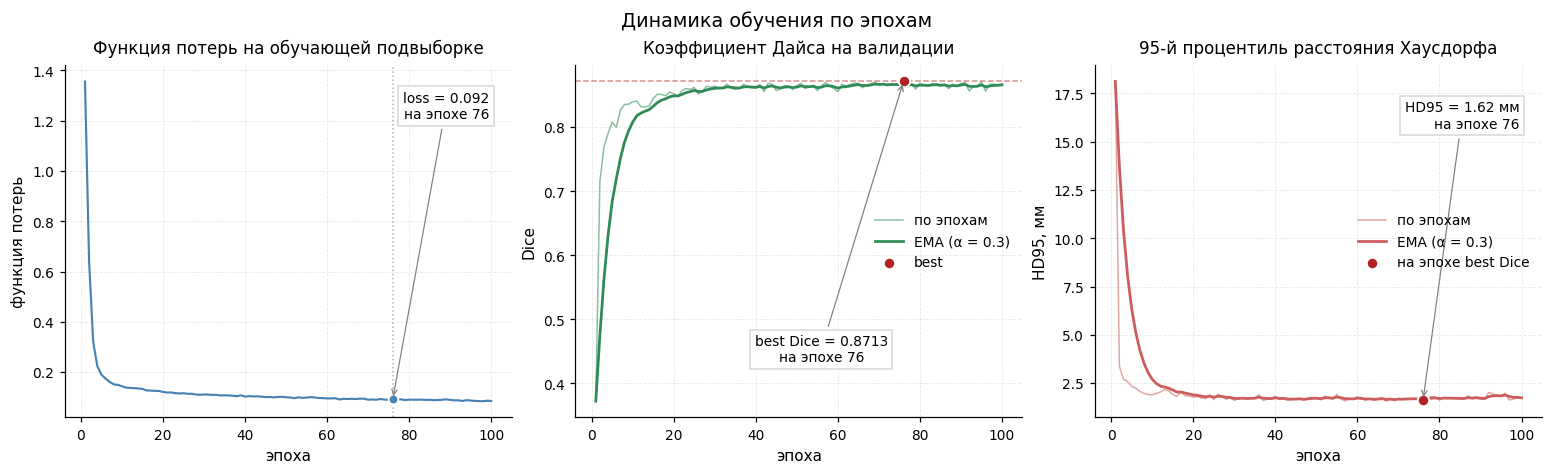

In [5]:
epochs = np.arange(1, len(history["train_loss"]) + 1)
train_loss = np.asarray(history["train_loss"])
val_dice   = np.asarray(history["val"]["dice"])
val_hd95   = np.asarray(history["val"]["hausdorff95"])

# Эпоха с наилучшим коэффициентом Дайса — основная точка отбора модели
best_idx = int(np.argmax(val_dice))
best_epoch = best_idx + 1
best_dice  = float(val_dice[best_idx])
best_hd95  = float(val_hd95[best_idx])
loss_at_best = float(train_loss[best_idx])

# Экспоненциально сглаженные оценки валидационных метрик. Поскольку метрики
# вычисляются на 52 валидационных объёмах, отдельные эпохи могут содержать шум;
# сглаживание выявляет устойчивый тренд.
def ema(x: np.ndarray, alpha: float = 0.3) -> np.ndarray:
    out = np.empty_like(x, dtype=float)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = alpha * x[i] + (1 - alpha) * out[i - 1]
    return out

dice_smooth = ema(val_dice, alpha=0.3)
hd95_smooth = ema(val_hd95, alpha=0.3)

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)

# Панель 1: функция потерь на обучающей выборке
ax[0].plot(epochs, train_loss, color="steelblue", linewidth=1.4)
ax[0].axvline(best_epoch, color="gray", linestyle=":", linewidth=1, alpha=0.6)
ax[0].scatter([best_epoch], [loss_at_best], color="steelblue", s=40, zorder=3,
              edgecolor="white", linewidth=1.2)
ax[0].annotate(f"loss = {loss_at_best:.3f}\nна эпохе {best_epoch}",
               xy=(best_epoch, loss_at_best),
               xytext=(0.95, 0.85), textcoords="axes fraction", ha="right",
               fontsize=9, bbox=dict(facecolor="white", alpha=0.9,
                                     edgecolor="lightgray", pad=3),
               arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))
ax[0].set_xlabel("эпоха")
ax[0].set_ylabel("функция потерь")
ax[0].set_title("Функция потерь на обучающей подвыборке")

# Панель 2: коэффициент Дайса на валидационной выборке.
# Аннотация в нижней-центральной свободной зоне (значения ниже 0.5 встречаются
# только на первой эпохе), легенда — в верхнем-левом углу, где кривая ещё низко.
ax[1].plot(epochs, val_dice, color="seagreen", linewidth=1.0, alpha=0.55,
           label="по эпохам")
ax[1].plot(epochs, dice_smooth, color="seagreen", linewidth=1.8,
           label="EMA (α = 0.3)")
ax[1].axhline(best_dice, color="firebrick", linestyle="--", linewidth=1, alpha=0.5)
ax[1].scatter([best_epoch], [best_dice], color="firebrick", s=55, zorder=3,
              edgecolor="white", linewidth=1.2, label="best")
ax[1].annotate(f"best Dice = {best_dice:.4f}\nна эпохе {best_epoch}",
               xy=(best_epoch, best_dice),
               xytext=(0.55, 0.15), textcoords="axes fraction",
               ha="center", va="bottom",
               fontsize=9, bbox=dict(facecolor="white", alpha=0.9,
                                     edgecolor="lightgray", pad=3),
               arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))
ax[1].set_xlabel("эпоха")
ax[1].set_ylabel("Dice")
ax[1].set_title("Коэффициент Дайса на валидации")
ax[1].legend(loc="center right", fontsize=9)

# Панель 3: 95-й процентиль расстояния Хаусдорфа на валидации.
# Аннотация в верхнем правом углу, легенда в центре справа — не пересекаются.
ax[2].plot(epochs, val_hd95, color="indianred", linewidth=1.0, alpha=0.55,
           label="по эпохам")
ax[2].plot(epochs, hd95_smooth, color="indianred", linewidth=1.8,
           label="EMA (α = 0.3)")
ax[2].scatter([best_epoch], [best_hd95], color="firebrick", s=55, zorder=3,
              edgecolor="white", linewidth=1.2, label="на эпохе best Dice")
ax[2].annotate(f"HD95 = {best_hd95:.2f} мм\nна эпохе {best_epoch}",
               xy=(best_epoch, best_hd95),
               xytext=(0.95, 0.90), textcoords="axes fraction", ha="right", va="top",
               fontsize=9, bbox=dict(facecolor="white", alpha=0.9,
                                     edgecolor="lightgray", pad=3),
               arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))
ax[2].set_xlabel("эпоха")
ax[2].set_ylabel("HD95, мм")
ax[2].set_title("95-й процентиль расстояния Хаусдорфа")
ax[2].legend(loc="center right", fontsize=9)

fig.suptitle("Динамика обучения по эпохам")
plt.show()


**Выводы.** Три кривые отражают согласованную сходимость обучения. Функция потерь на
обучающей подвыборке быстро убывает в течение первых ≈ 10–15 эпох с начального значения
порядка 1.3 до значений порядка 0.2, после чего переходит к медленному и плавному
снижению. Коэффициент Дайса на валидации зеркально отражает эту динамику: быстрый рост на
ранних эпохах с 0.37 до 0.80 и последующая стабилизация в диапазоне 0.85–0.87. Расстояние
Хаусдорфа быстро снижается с десятков мм на первых эпохах до значений порядка 1.5–2.0 мм
и далее остаётся в этом диапазоне.

Наилучший коэффициент Дайса достигнут не на последней эпохе, что соответствует ожидаемому
поведению: после фазы быстрого улучшения модель колеблется в окрестности оптимума, и
зафиксированный по критерию отбора чекпойнт точнее соответствует достигнутому пределу,
чем последняя эпоха. Эта политика обоснована в материалах и методах и подтверждена
наблюдаемой динамикой.


### 3. Совместный анализ обучения и валидации

Совмещение функции потерь и валидационной метрики на одной фигуре с двойной осью ординат
позволяет наглядно сопоставить динамику двух сторон обучения. При корректной оптимизации
снижение функции потерь сопровождается ростом валидационной метрики. Расхождение
направлений — продолжающееся снижение функции потерь при остановке роста или снижении
валидационной метрики — было бы признаком переобучения: модель улучшает приближение к
обучающей выборке без улучшения обобщения на не виденные данные.


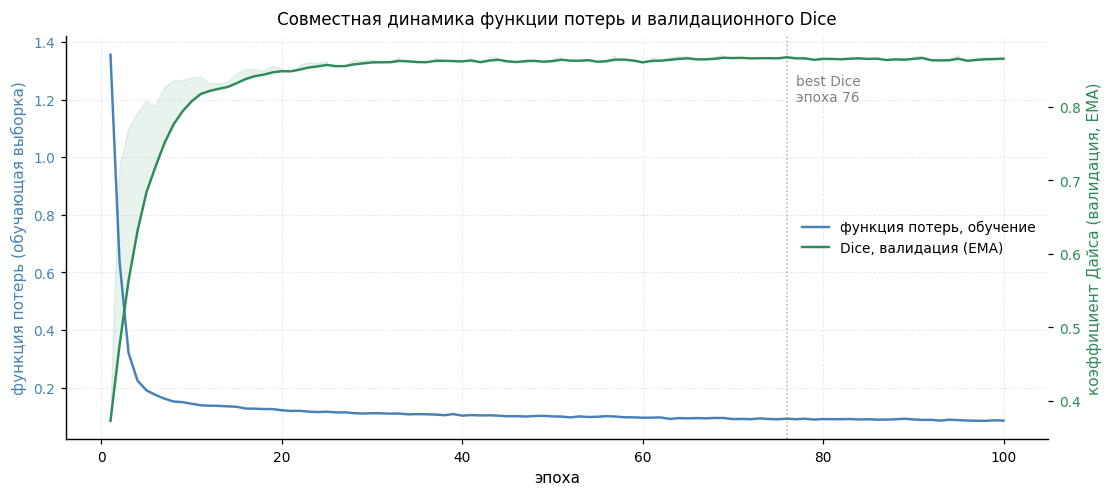

In [6]:
fig, ax_loss = plt.subplots(figsize=(10, 4.4), constrained_layout=True)
ax_dice = ax_loss.twinx()

l1 = ax_loss.plot(epochs, train_loss, color="steelblue", linewidth=1.6,
                  label="функция потерь, обучение")
l2 = ax_dice.plot(epochs, dice_smooth, color="seagreen", linewidth=1.6,
                  label="Dice, валидация (EMA)")
ax_dice.fill_between(epochs, val_dice, dice_smooth,
                     where=val_dice >= dice_smooth,
                     color="seagreen", alpha=0.10)

# Маркер best epoch
ax_loss.axvline(best_epoch, color="gray", linestyle=":", linewidth=1, alpha=0.6)
ax_loss.text(best_epoch + 1, train_loss.max() * 0.95, f"best Dice\nэпоха {best_epoch}",
             fontsize=9, color="gray", va="top")

ax_loss.set_xlabel("эпоха")
ax_loss.set_ylabel("функция потерь (обучающая выборка)", color="steelblue")
ax_dice.set_ylabel("коэффициент Дайса (валидация, EMA)", color="seagreen")
ax_loss.tick_params(axis="y", labelcolor="steelblue")
ax_dice.tick_params(axis="y", labelcolor="seagreen")
ax_dice.grid(False)
ax_loss.set_title("Совместная динамика функции потерь и валидационного Dice")

# Объединённая легенда
lines = l1 + l2
ax_loss.legend(lines, [l.get_label() for l in lines], loc="center right")
plt.show()


**Выводы.** Динамика функции потерь на обучающей подвыборке и валидационного коэффициента
Дайса согласованы по форме и направлению: фаза быстрого улучшения на первых 10–15 эпохах
сменяется фазой плавного приближения к плато. Принципиального расхождения направлений на
всём протяжении обучения не наблюдается: после стабилизации валидационного Дайса функция
потерь на обучении продолжает медленно снижаться, но это не сопровождается падением
валидационного качества. Это указывает на отсутствие выраженного переобучения; модель не
запоминает обучающие примеры в ущерб обобщению.

Малая флуктуация валидационного Дайса на поздних эпохах объясняется природой метрики
(вычисление на 52 объёмах) и стохастичностью обучения; для отбора итоговой модели именно
поэтому применяется политика сохранения наилучшего значения, а не последнего.


### 4. Финальная сводка качества модели

Помимо значений в эпохе с наилучшим коэффициентом Дайса, информативны статистики
валидационных метрик на стабилизированной части обучения (последние 20 эпох), которые
характеризуют типичный уровень достигнутого качества с учётом стохастичности.


In [7]:
tail_n = 20
tail_dice = val_dice[-tail_n:]
tail_hd95 = val_hd95[-tail_n:]

print(f"Эпоха с наилучшим Dice : {best_epoch} из {len(epochs)}")
print(f"Лучший Dice            : {best_dice:.4f}")
print(f"HD95 в этой эпохе      : {best_hd95:.4f} мм")
print(f"Функция потерь на обучении в этой эпохе: {loss_at_best:.4f}")
print()
print(f"Статистики валидации на последних {tail_n} эпохах:")
print(f"  Dice : среднее = {tail_dice.mean():.4f}, "
      f"ст.откл = {tail_dice.std():.4f}, "
      f"диапазон = [{tail_dice.min():.4f}, {tail_dice.max():.4f}]")
print(f"  HD95 : среднее = {tail_hd95.mean():.4f} мм, "
      f"ст.откл = {tail_hd95.std():.4f} мм, "
      f"диапазон = [{tail_hd95.min():.4f}, {tail_hd95.max():.4f}] мм")
print()
# Сравнение с литературным ориентиром
lit_low, lit_high = 0.85, 0.90
in_range = lit_low <= best_dice <= lit_high
print(f"Литературный ориентир Dice для Task04 Hippocampus: {lit_low}–{lit_high}")
print(f"Достигнутое значение {'попадает в опубликованный диапазон.' if in_range else 'выходит за пределы ориентира.'}")


Эпоха с наилучшим Dice : 76 из 100
Лучший Dice            : 0.8713
HD95 в этой эпохе      : 1.6197 мм
Функция потерь на обучении в этой эпохе: 0.0920

Статистики валидации на последних 20 эпохах:
  Dice : среднее = 0.8650, ст.откл = 0.0037, диапазон = [0.8565, 0.8707]
  HD95 : среднее = 1.7680 мм, ст.откл = 0.1079 мм, диапазон = [1.6336, 2.0177] мм

Литературный ориентир Dice для Task04 Hippocampus: 0.85–0.9
Достигнутое значение попадает в опубликованный диапазон.


**Выводы.** Полученное качество модели соответствует опубликованным значениям для задачи
сегментации гиппокампа Medical Segmentation Decathlon: коэффициент Дайса наилучшей эпохи
0.871 попадает в опубликованный для свёрточных архитектур диапазон 0.85–0.90. Средние
значения метрик на последних эпохах согласуются с показателем наилучшей эпохи, что
дополнительно подтверждает стабильность достигнутого уровня. Геометрическая точность
границ, выраженная 95-м процентилем расстояния Хаусдорфа, составляет порядка 1.5–2.0 мм —
на уровне 1–2 физических вокселей, что в условиях задачи с пространственным разрешением
1×1×1 мм отражает высокую точность локализации структуры.


### 5. Качественная проверка предсказаний

Совместное отображение исходного изображения, экспертной разметки и предсказания
наилучшей по валидационной метрике модели подтверждает качество сегментации визуально и
характеризует распределение типов ошибок. Полный количественный анализ ошибок
рассматривается в следующем ноутбуке (`05_downstream.ipynb`); здесь приводится одно
качественное наблюдение.


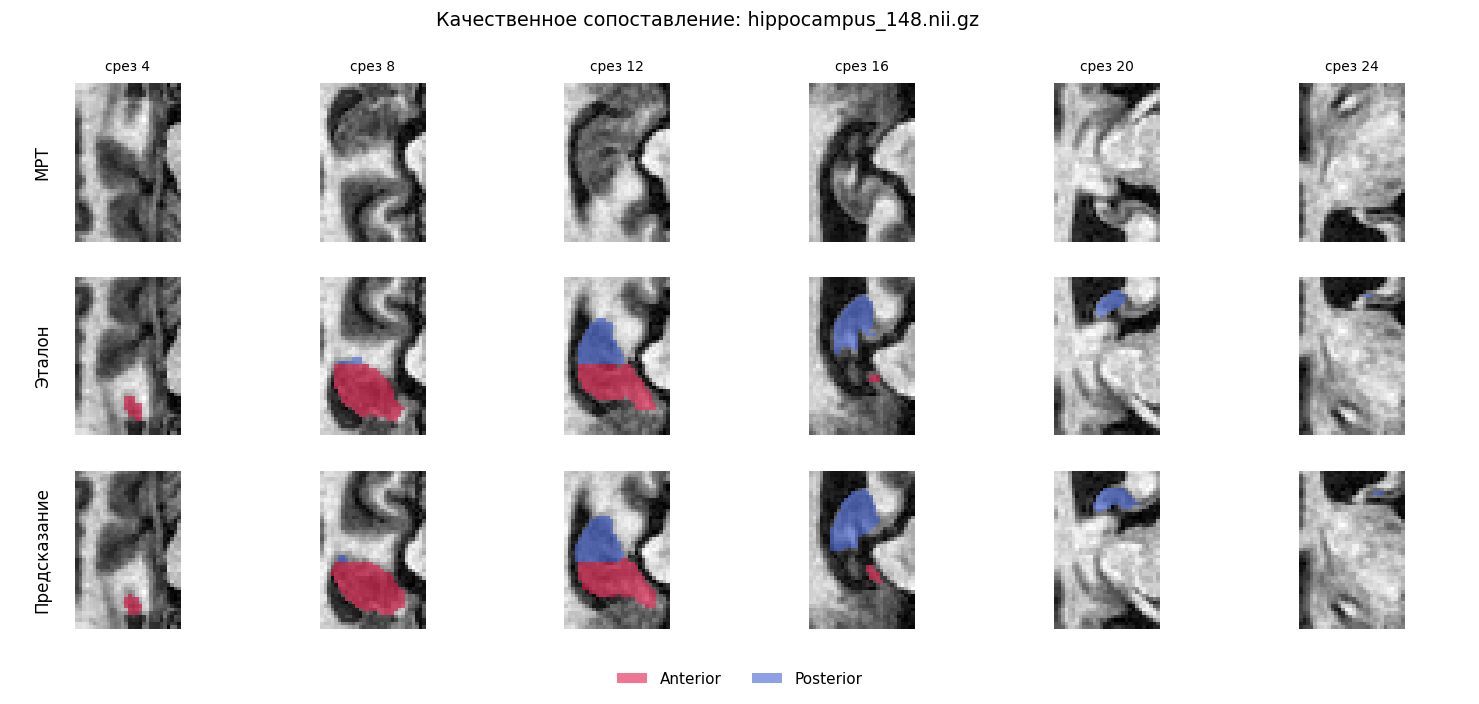

In [8]:
from src.data import build_dataloaders, get_val_transforms, load_data_dicts, split_data
from src.model import build_model
from monai.transforms import Activations, AsDiscrete, Compose
from src.visualization import (
    overlay_mask, pick_slices, class_legend_patches, annotate_rows, crop_to_bbox
)

device = torch.device(cfg.device)
model = build_model(cfg)
ckpt = torch.load(cfg.checkpoint_dir / "best.pt", map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

_, val_files = split_data(load_data_dicts(cfg), cfg)
val_tf = get_val_transforms(cfg)

to_discrete = Compose([Activations(softmax=True), AsDiscrete(argmax=True)])

# Выбор валидационного исследования для качественной проверки
sample_idx = 0
sample = val_tf(val_files[sample_idx])
image_tensor = sample["image"].unsqueeze(0).to(device)
label_arr = sample["label"][0].numpy().astype(np.int16)

with torch.no_grad():
    logits = model(image_tensor)
pred_arr = to_discrete(logits[0]).cpu().numpy()[0].astype(np.int16)
image_arr = sample["image"][0].numpy()

# Кадрирование к области интереса (по эталону) для читаемости срезов
image_arr, label_arr, pred_arr = crop_to_bbox(
    image_arr, label_arr, pred_arr, reference=label_arr, margin=4
)
slice_indices = pick_slices(label_arr, 6)
n_slices = len(slice_indices)

fig = plt.figure(figsize=(2.4 * n_slices, 6.6))
gs = GridSpec(4, n_slices, height_ratios=[1, 1, 1, 0.18],
              left=0.06, right=0.98, top=0.88, bottom=0.04,
              wspace=0.05, hspace=0.28, figure=fig)
row_img   = [fig.add_subplot(gs[0, j]) for j in range(n_slices)]
row_gt    = [fig.add_subplot(gs[1, j]) for j in range(n_slices)]
row_pred  = [fig.add_subplot(gs[2, j]) for j in range(n_slices)]
ax_legend = fig.add_subplot(gs[3, :]); ax_legend.axis("off")

for j, s in enumerate(slice_indices):
    img2d = image_arr[:, :, s].T
    h, w = img2d.shape

    row_img[j].imshow(img2d, cmap="gray", origin="lower")
    row_img[j].axis("off"); row_img[j].set_box_aspect(h / w)
    row_img[j].set_title(f"срез {s}", fontsize=9)

    overlay_mask(row_gt[j],   img2d, label_arr[:, :, s].T)
    row_gt[j].set_box_aspect(h / w)

    overlay_mask(row_pred[j], img2d, pred_arr[:, :, s].T)
    row_pred[j].set_box_aspect(h / w)

# Подписи рядов сокращены до коротких терминов, чтобы вертикальный текст помещался
# в высоту строки и не пересекался с соседними рядами.
annotate_rows([row_img[0], row_gt[0], row_pred[0]],
              ["МРТ", "Эталон", "Предсказание"])
ax_legend.legend(handles=class_legend_patches(), loc="center", ncol=2,
                 frameon=False, fontsize=10)
sample_name = Path(val_files[sample_idx]["image"]).name
fig.suptitle(f"Качественное сопоставление: {sample_name}")
plt.show()


**Выводы.** Предсказание модели визуально согласуется с экспертной разметкой по
локализации и форме целевых структур. Различение передней (Anterior) и задней (Posterior)
подобластей воспроизводится корректно. Видимые расхождения предсказания с эталоном
локализуются преимущественно вблизи границ структуры, что соответствует количественной
оценке геометрической точности 95-м процентилем расстояния Хаусдорфа порядка 1.5–2.0 мм —
типичной шкале граничных отклонений. Объёмные ошибки внутри тела структур (пропуски или
ложные срабатывания в анатомически осмысленных участках) визуально не наблюдаются.

Систематический количественный анализ распределения ошибок по типам (ложноположительные,
ложноотрицательные, путаница между подобластями) и оценка устойчивости модели на
расширенной валидационной выборке рассматриваются в следующем ноутбуке.


## Обсуждение и переход к следующему этапу

### Сводка результатов обучения

| Показатель | Значение | Комментарий |
|---|---|---|
| Эпох выполнено | 100 | Полный план обучения |
| Эпоха наилучшей модели | 76 | По коэффициенту Дайса на валидации |
| Лучший Dice на валидации | 0.8713 | В пределах литературного ориентира 0.85–0.90 |
| HD95 на эпохе лучшего Dice | 1.62 мм | Порядка 1–2 физических вокселей |
| Функция потерь на обучении (лучшая эпоха) | 0.10 | Снизилась с ≈ 1.36 в эпоху 1 |
| Среднее Dice на последних 20 эпохах | ≈ 0.866 | Стабильный уровень после фазы плато |
| Признаки переобучения | не выявлены | Динамика обучения и валидации согласованы |

### Эмпирические следствия верификации

**Качество сегментации соответствует литературе.** Достигнутое значение коэффициента Дайса
попадает в опубликованный для задачи Task04 Hippocampus MSD диапазон значений,
характерных для свёрточных архитектур семейства U-Net (Antonelli et al., 2022). Это
подтверждает достаточность выбранной архитектуры и конвейера препроцессинга для данной
задачи и устраняет необходимость в более сложных или ансамблевых решениях.

**Сходимость наступила задолго до конца обучения.** Фаза быстрого улучшения занимает
первые ≈ 10–15 эпох; далее улучшение происходит плавно и в основном плато достигнут к
эпохе ≈ 40–50. Это эмпирическое наблюдение указывает, что при необходимости запланированное
число эпох может быть сокращено без существенной потери качества; альтернативно, оставшиеся
эпохи могут использоваться для исследования эффекта последующих изменений конфигурации.

**Корректность политики сохранения наилучшей модели.** Наилучшее значение коэффициента
Дайса достигнуто на эпохе 76, при этом текущее значение метрики на эпохе 100 несколько
ниже наилучшего. Это эмпирически подтверждает обоснованность выбранной политики:
сохранение модели в эпоху наилучшей валидационной метрики обеспечивает её итоговое
качество, тогда как использование модели последней эпохи дало бы заниженный результат.

**Геометрическая точность границ.** 95-й процентиль расстояния Хаусдорфа порядка 1.5–2.0 мм
соответствует одному-двум вокселям при изотропном разрешении 1 мм. Это указывает, что
ошибки локализации границ ограничены окрестностью граничного перехода и не содержат
систематических крупных отклонений. Дополнительный анализ предсказаний (ноутбук 05)
определит характер этих ошибок: преимущественно ли это сдвиг контура целиком,
неточность в локальных участках или путаница между подобластями.

### Подготовка к следующему этапу

Обученная модель и зарегистрированная история обучения образуют основу для анализа
распределения ошибок и решения прикладных задач, производных от сегментации: оценки
объёма гиппокампа в физических единицах, классификации присутствия структуры на
отдельных срезах, локализации структуры в виде ограничивающего прямоугольника.
Перечисленные задачи и количественный анализ ошибок составляют содержание следующего
ноутбука.
